# Contacts vs distance

### Setup

Welcome to the cooltools expected & contacts-vs-distance notebook!

In Hi-C maps, contact frequency decreases very strongly with **genomic separation** (also referred to as **genomic distance**). In the Hi-C field, this decay is often interchangeably referred to as the: 

* **expected** because one "expects" a certain average contact frequency at a given genomic separation
* **scaling** which is borrowed from the polymer physics literature
* **P(s) curve** contact *probability*, *P*, as a function of genomic *separation*, *s*. 

The rate of decay of contacts with genomic separation reflects the polymeric nature of chromosomes and can tell us about the global folding patterns of the genome. 

This decay has been observed to vary through the cell cycle, across cell types, and after degredation of structural maintenance of chromosomes complexes (SMCs) in both interphase and mitosis. 

The goals of this notebook are to:

* calculate the P(s) of a given cooler
* plot the P(s) curve
* smooth the P(s) curve with logarithmic binning
* plot the derivative of P(s)
* plot the P(s) between two different genomic regions
* plot the matrix of average contact frequencies between different chromosomes

In [1]:
%load_ext autoreload
%autoreload 2 

In [1]:
# import core packages
import warnings
warnings.filterwarnings("ignore")
from itertools import combinations
import os

# import semi-core packages
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
plt.style.use('seaborn-v0_8-poster')
import numpy as np
import pandas as pd
from multiprocessing import Pool

# import open2c libraries
import bioframe

import cooler
import cooltools

from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.2'):
    raise AssertionError("tutorial relies on cooltools version 0.5.2 or higher,"+
                         "please check your cooltools version and update to the latest")

# count cpus
num_cpus = os.getenv('SLURM_CPUS_PER_TASK')
if not num_cpus:
    num_cpus = os.cpu_count()
num_cpus = int(num_cpus)

### Load cooler file

In [280]:
# mcool_file = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Raw.100K/L2_3_IT_CTX_Glut.Raw.100K.mcool'
mcool_file = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Q.100K/selected/L2_3_IT_CTX_Glut.Q.100K.mcool'

resolution = int(1000 * 1000 * 2.5) # 2.5 Mb (2.5e6 bp)
uri = f'{mcool_file}::/resolutions/{resolution:g}'

clr = cooler.Cooler(uri)

cis_cov, tot_cov = cooltools.coverage(clr, ignore_diags=1, nproc=2)
print(f"nreads: {cis_cov.sum():,}", flush=True)

### Load genome data

In addition to data stored in a cooler, the analyses below make use
of where chromosomal arms start and stop to calculate contact frequency versus distance curves
within arms. For commonly-used genomes, bioframe can be used to fetch these 
annotations directly from UCSC. For less commonly-used genomes, a table of arms, or chromosomes 
can be loaded in directly with pandas, e.g.  

`chromsizes = pd.read_csv('chrom.sizes', sep='\t')`

Regions for calculating expected should be provided as a [viewFrame](https://bioframe.readthedocs.io/en/latest/guide-intervalops.html#genomic-views), i.e. a dataframe with four columns, chrom, start, stop, name,
where entries in the name column are unique and the intervals are non-overlapping. If the chromsizes table does not have a name column, it can be created with  `bioframe.core.construction.add_ucsc_name_column(bioframe.make_viewframe(chromsizes))`.

In [307]:
# cooler.binnify(mm10_chromsizes, resolution)

In [86]:
# https://hgdownload.soe.ucsc.edu/goldenPath/mm10/database/
# https://genome.ucsc.edu/cgi-bin/hgTables?db=hg19&hgta_group=map&hgta_track=gap&hgta_table=gap&hgta_doSchema=describe+table+schema

# print(bioframe.fetch_chromsizes('hg38').head(2).to_string())
# bioframe.fetch_centromeres('hg38').head(2)
# # bioframe.fetch_centromeres('hg38').sort_values('start').set_index('chrom') / 100000  #.head(2)

mm10_gap = pd.read_csv(
    '/net/gs/vol1/home/gesine/noble_lab/resources/genomic/gaps/ucsc.mm10.gap.txt',
    sep='\t', header=None, names=(
        'bin', 'chrom', 'start', 'end', 'ix', 'n', 'size', 'type', 'bridge'))

mm10_cens = mm10_gap.loc[mm10_gap.type == 'centromere', ['chrom', 'start', 'end']].copy().reset_index()
# mm10_cens.set_index('chrom', inplace=True); mm10_cens['chromsize'] = mm10_chromsizes[mm10_cens.index]
# mm10_cens[['start', 'end']] += mm10_cens[['chromsize']].values
mm10_cens['mid'] = ((mm10_cens.start + mm10_cens.end) / 2).astype(int)

In [354]:
# Use bioframe to fetch the genomic features from the UCSC.
mm10_chromsizes = bioframe.fetch_chromsizes('mm10')
# mm10_cens = bioframe.fetch_centromeres('mm10')  # Only available for human
# create a view with chromosome arms using chromosome sizes and definition of centromeres
mm10_arms = bioframe.make_chromarms(mm10_chromsizes,  mm10_cens)

# select only those chromosomes available in cooler
mm10_arms = mm10_arms[mm10_arms.chrom.isin(clr.chromnames)].reset_index(drop=True)

# GC: remove chrX, chrY, chrM
mm10_arms = mm10_arms[~mm10_arms.chrom.isin(['chrX', 'chrY', 'chrM'])].reset_index(drop=True)

# GC: remove arms that are less than the current binsize/resolution
mm10_arms = mm10_arms[(mm10_arms.end - mm10_arms.start)  > resolution]

mm10_arms.head()

,chrom,start,end,name
1,chr1,1555000,195471971,chr1_q
3,chr2,1555000,182113224,chr2_q
5,chr3,1555000,160039680,chr3_q
7,chr4,1555000,156508116,chr4_q
9,chr5,1555000,151834684,chr5_q


### Calculate the P(s) curve

To calculate the average contact frequency as a function of genomic separation, we use the fact that each diagonal of a Hi-C map records contacts between loci separated by the same genomic distance. For example, the 3rd diagonal of a matrix at 1kb resolution contains contacts between loci separated by 3-4kb (note that diagonals are 0-indexed). Thus, we calculate the average contact frequency, *P(s)*, at a given genomic distance, *s*, as the average value of all pixels of the corresponding diagonal. This operation is performed by `cooltools.expected_cis`.

Note that we calculate the *P(s)* separately for each chromosomal **arm**, by providing  `mm10_arms` as a `view_df`. This way we will ignore contacts accross the centromere, which is generally a good idea, since such contacts have a slightly different decay versus genomic separation.

In [356]:
# cvd == contacts-vs-distance
cvd = cooltools.expected_cis(
    clr=clr,
    view_df=mm10_arms,
    smooth=False,
    aggregate_smoothed=False,
    nproc=num_cpus, #if you do not have multiple cores available, set to 1
    ignore_diags=1, # GC: Given very coarse bin size, only ignore main diagonal
    intra_only=True,  # GC: snm3C-seq data only contains intra-chrom counts
    #clr_weight_name=None,
)

INFO:root:creating a Pool of 32 workers


This function calculates average contact frequency for raw and normalized interactions ( `count.avg` and `balanced.avg`) for each diagonal and each regions in the `mm10_arms` of a Hi-C map. It aslo keeps the sum of raw and normalized interaction counts (`count.sum` and `balanced.sum`) as well as the number of valid (i.e. non-masked) pixels at each diagonal, `n_valid`.

In [351]:
display(cvd.head(4))
display(cvd.tail(4))

,region1,region2,dist,dist_bp,contact_frequency,n_total,n_valid,count.sum,balanced.sum,count.avg,balanced.avg
0,chr1_p,chr1_p,0,0,NaN,1,0,NaN,NaN,NaN,NaN
1,chr1_q,chr1_q,0,0,NaN,79,77,NaN,NaN,NaN,NaN
2,chr1_q,chr1_q,1,2500000,0.234973,78,76,175.836288,17.857979,2.254311,0.234973
3,chr1_q,chr1_q,2,5000000,0.054305,77,75,42.111202,4.072888,0.546899,0.054305


,region1,region2,dist,dist_bp,contact_frequency,n_total,n_valid,count.sum,balanced.sum,count.avg,balanced.avg
1009,chr19_q,chr19_q,21,52500000,0.048534,4,3,0.657960,0.145601,0.164490,0.048534
1010,chr19_q,chr19_q,22,55000000,0.039561,3,2,0.277565,0.079122,0.092522,0.039561
1011,chr19_q,chr19_q,23,57500000,0.048219,2,1,0.166949,0.048219,0.083475,0.048219
1012,chr19_q,chr19_q,24,60000000,NaN,1,0,0.000000,0.000000,0.000000,NaN


Note that the data from the first couple of diagonals are masked. This is done intentionally, since interactions at these diagonals (very short-ranged) are contaminated by non-informative Hi-C byproducts - dangling ends and self-circles. 

### Plot the P(s) curve

Time to plot *P(s)* !

The first challenge  is that Hi-C has a very wide dynamic range. Hi-C probes genomic separations ranging from 100s to 100,000,000s of basepairs and contact frequencies also tend to span many orders of magnitude.

Plotting such data in the linear scale would reveal only a part of the whole picture. Instead, we typically switch to double logarithmic (aka log-log) plots, where the x and y coordinates vary by orders of magnitude.

With the flags used above, `expected_cis()` does not smooth or aggregate across regions. This can lead to noisy P(s) curves for each region:

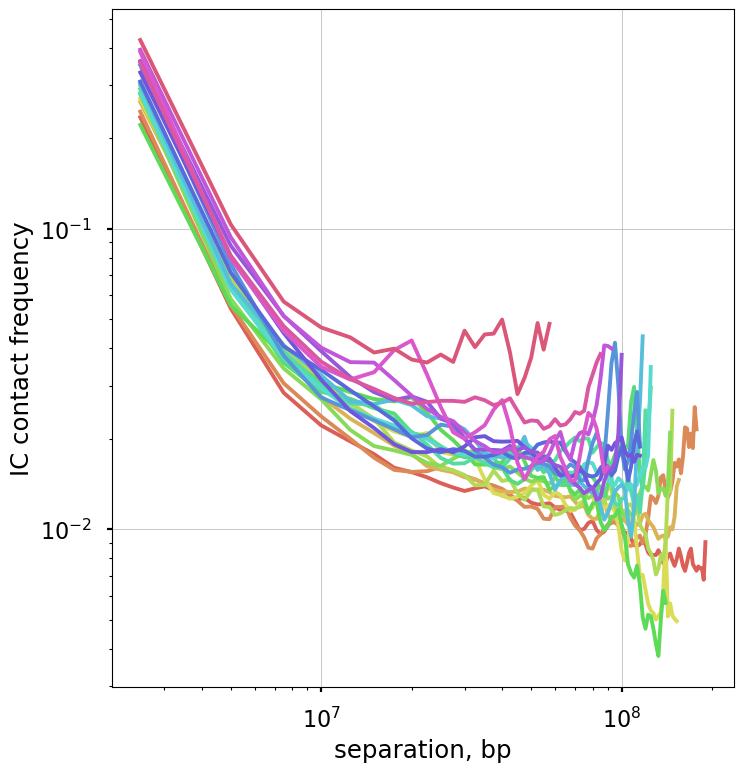

In [359]:
f, ax = plt.subplots(1,1)

chromosomes = mm10_arms.chrom.drop_duplicates().reset_index(drop=True)
chromosomes = chromosomes[chromosomes.isin(clr.chromnames)]
cmap = sns.color_palette("hls", len(chromosomes))
cmap_dict = {chromosomes[i]: cmap[i] for i in range(len(chromosomes))}

for i, row in mm10_arms.iterrows():
    region = row['name']
    color = cmap_dict[row.chrom]
    linestyle = '--' if ('p' in region) else '-'
    alpha = 0.75 if ('p' in region) else 1

    ax.loglog(
        cvd['dist_bp'].loc[cvd['region1']==region],
        cvd['contact_frequency'].loc[cvd['region1']==region],
        color=color, linestyle=linestyle, label=region, alpha=alpha)
    ax.set(
        xlabel='separation, bp',
        ylabel='IC contact frequency')
    ax.set_aspect(1.0)
    ax.grid(lw=0.5)

# plt.legend()
plt.show()

The non-smoothed curves plotted above form characteristic "fans" at longer separations. This happens for two reasons: (a) we plot values of **each** diagonal separately and thus each decade of s contains 10x more points, and (b) due to the polymer nature of chromosomes, contact frequency at large genomic separations are lower and thus more affected by sequencing depth.

This issue is more that just cosmetic, as this noise would prevent us from doing finer analyses of *P(s)* and propagate into data derived from *P(s)*. However, there is a simple solution: we can smooth *P(s)* over multiple diagonals. This works because *P(s)* changes very gradually with *s*, so that consecutive diagonals have similar values. Furthermore, we can make each subsequent smoothing window wider than the previous one, so that each order of magnitude of genomic separation contains the same number of windows. Such aggregation is a little tricky to perform, so `cooltools.expected` implements this operation.

### Smoothing & aggregating P(s) curves

Instead of the flags above, we can pass flags to `expected_cis()` that return smoothed and aggregated columns for futher analysis (which are on by default).

Note that the plots below use smooth_sigma=0.1, which is relatively conservative, and this parameter can be lowered (with discretion) for sufficiently high-resolution datasets.

In [360]:
# cvd == contacts-vs-distance
cvd = cooltools.expected_cis(
    clr=clr,
    view_df=mm10_arms,
    smooth=False,
    aggregate_smoothed=False,
    nproc=num_cpus, #if you do not have multiple cores available, set to 1
    ignore_diags=1, # GC: Given very coarse bin size, only ignore main diagonal
    intra_only=True,  # GC: snm3C-seq data only contains intra-chrom counts
    #clr_weight_name=None,
)

cvd_smooth_agg = cooltools.expected_cis(
    clr=clr,
    view_df=mm10_arms,
    smooth=True,
    aggregate_smoothed=True,
    smooth_sigma=0.1,
    nproc=num_cpus,
    ignore_diags=1, # GC: Given very coarse bin size, only ignore main diagonal
    intra_only=True,  # GC: snm3C-seq data only contains intra-chrom counts
    #clr_weight_name=None,
)

INFO:root:creating a Pool of 32 workers


In [286]:
display(cvd_smooth_agg.head(4))

,region1,region2,dist,dist_bp,contact_frequency,n_total,n_valid,count.sum,balanced.sum,count.avg,balanced.avg,balanced.avg.smoothed,balanced.avg.smoothed.agg
0,chr1_p,chr1_p,0,0,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN
1,chr1_q,chr1_q,0,0,NaN,79,77,NaN,NaN,NaN,NaN,NaN,NaN
2,chr1_q,chr1_q,1,2500000,0.295049,78,76,175.836288,17.857979,2.254311,0.234973,0.233071,0.295049
3,chr1_q,chr1_q,2,5000000,0.065291,77,75,42.111202,4.072888,0.546899,0.054305,0.051226,0.065291


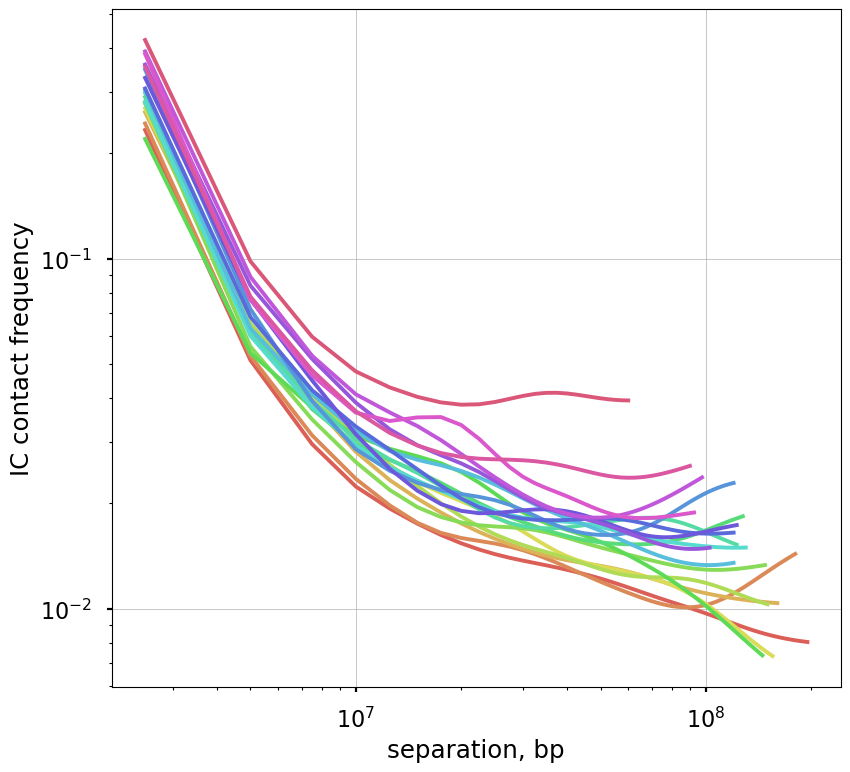

In [361]:
# cvd_smooth_agg['balanced.avg.smoothed'].loc[cvd_smooth_agg['dist'] < 2] = np.nan  # GC: comment out

f, ax = plt.subplots(1,1)

chromosomes = mm10_arms.chrom.drop_duplicates().reset_index(drop=True)
chromosomes = chromosomes[chromosomes.isin(clr.chromnames)]
cmap = sns.color_palette("hls", len(chromosomes))
cmap_dict = {chromosomes[i]: cmap[i] for i in range(len(chromosomes))}

for i, row in mm10_arms.iterrows():
    region = row['name']
    color = cmap_dict[row.chrom]
    linestyle = '--' if ('p' in region) else '-'
    alpha = 0.75 if ('p' in region) else 1

    ax.loglog(
        cvd_smooth_agg['dist_bp'].loc[cvd_smooth_agg['region1']==region],
        cvd_smooth_agg['balanced.avg.smoothed'].loc[cvd_smooth_agg['region1']==region],
        color=color, linestyle=linestyle, label=region, alpha=alpha)
    ax.set(
        xlabel='separation, bp', 
        ylabel='IC contact frequency')
    ax.set_aspect(1.0)
    ax.grid(lw=0.5)

# plt.legend()
plt.show()

The `balanced.avg.smoothed.agg` is averaged across regions, and shows the same exact curve for each.

In [301]:
import jax.numpy as jnp
from jax import grad
from scipy import optimize
from estimate_alpha import print_alpha_infer_results


def estimate_scaling_factor(exponent, genomic_dis, data):
    y = jnp.power(genomic_dis, exponent)
    scaling_factor = jnp.sum(y * data) / jnp.sum(jnp.square(y))
    return scaling_factor


def fit_exponent_obj(exponent, genomic_dis, data, scaling_factor):
    y = scaling_factor * jnp.power(genomic_dis, exponent)
    mse = jnp.mean(jnp.square(data - y))
    return mse


fit_exponent_grad = grad(fit_exponent_obj)


def obj_wrap(exponent, genomic_dis, data):
    scaling_factor = estimate_scaling_factor(exponent, genomic_dis=genomic_dis, data=data)
    obj = fit_exponent_obj(exponent, genomic_dis=genomic_dis, data=data, scaling_factor=scaling_factor)
    if not isinstance(obj, float) and obj.size > 1:
        obj = sum(obj)
    return obj


def grad_wrap(exponent, genomic_dis, data):
    scaling_factor = estimate_scaling_factor(exponent, genomic_dis=genomic_dis, data=data)
    return np.array(fit_exponent_grad(exponent, genomic_dis=genomic_dis, data=data, scaling_factor=scaling_factor)).ravel()


def estimate_exponent(cvd_smooth_agg, x0=None, bounds=(-10, 10), seed=0,
                      min_genomic_dis=None, max_genomic_dis='default',
                      max_iter=1e20, verbose=False):
    # Define initial value (x0) and bounds on X
    if x0 is None:
        rng = np.random.default_rng(seed=seed)
        x0 = rng.uniform(low=bounds[0], high=bounds[1])
    x0 = np.array(x0, ndmin=1, copy=None)
    bounds = np.array(bounds, ndmin=2, copy=None).reshape(1, -1)

    # Build args
    dist_decay = cvd_smooth_agg.loc[~pd.isnull(
        cvd_smooth_agg['balanced.avg.smoothed.agg']), ['dist_bp', 'balanced.avg.smoothed.agg']].groupby(
        'dist_bp').mean()
    if min_genomic_dis is None:
        min_genomic_dis = dist_decay.index.min()
    if max_genomic_dis is None:
        max_genomic_dis = dist_decay.index.max()
    elif isinstance(max_genomic_dis, str) and max_genomic_dis.lower() == 'default':
        max_genomic_dis = cvd_smooth_agg[~pd.isnull(
            cvd_smooth_agg['balanced.avg.smoothed.agg'])].groupby(
            'region1').max().dist_bp.min()
    mask = (dist_decay.index <= max_genomic_dis) & (dist_decay.index >= min_genomic_dis)
    genomic_dis = dist_decay[mask].index.values
    data = dist_decay[mask].values.ravel()
    args = [genomic_dis, data]

    # Optimize
    if verbose:
        print("OPTIMIZING:", flush=True)
    obj = obj_wrap(x0, *args)
    if max_iter == 0:
        X = x0
        d = {'converged': 'N/A', 'obj': obj._value}
    else:
        results = optimize.fmin_l_bfgs_b(
            obj_wrap, x0=x0, fprime=grad_wrap, bounds=bounds, args=args,
            factr=1e-20, maxls=40, pgtol=1e-10, maxiter=int(max_iter)) #, maxfun=max_fun)
        X, obj, d = results
        d['converged'] = d['warnflag'] == 0
        conv_desc = d['task']
        d['obj'] = obj
    if X.size == 1:
        d['exponent'] = X[0]
    else:
        d['exponent'] = X
    d['scaling_factor'] = float(estimate_scaling_factor(X, *args)._value)

    if verbose:
        print("\nRESULTS:", flush=True)
        print_alpha_infer_results(d)

    return d

In [302]:
estimate_exponent(
    cvd_smooth_agg, seed=0, min_genomic_dis=None, max_genomic_dis='default',
    verbose=True)

OPTIMIZING:

RESULTS:
grad         -4.78e-11
task         CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
funcalls     30
nit          8
warnflag     0
converged    True
obj          0.000163
exponent     -1.55
scaling_factor   2.45e+09


{'grad': array([-4.78306293e-11]),
 'task': 'CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL',
 'funcalls': 30,
 'nit': 8,
 'warnflag': 0,
 'converged': True,
 'obj': 0.00016271357750326086,
 'exponent': np.float64(-1.5524087518391956),
 'scaling_factor': 2446199652.334744}

2445227981.741547


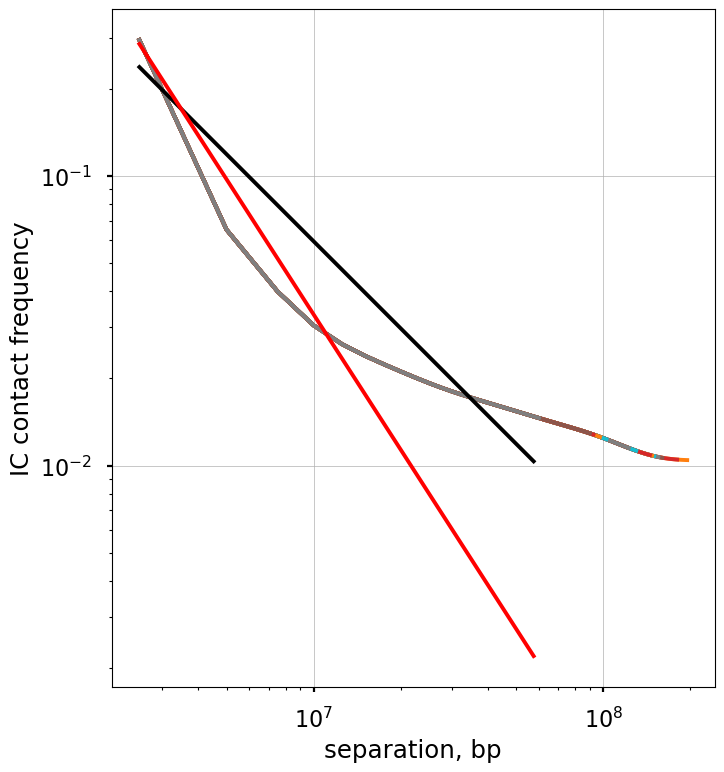

In [303]:
dist_decay = cvd_smooth_agg.loc[~pd.isnull(
    cvd_smooth_agg['balanced.avg.smoothed.agg']), ['dist_bp', 'balanced.avg.smoothed.agg']].groupby(
    'dist_bp').mean()
# foo = cvd_smooth_agg.loc[~pd.isnull(cvd_smooth_agg['balanced.avg.smoothed.agg']), ['dist_bp', 'balanced.avg.smoothed.agg']]
# x = np.power(10, np.linspace(np.log10(foo['dist_bp'].min()), np.log10(foo['dist_bp'].max()), 100))
x = dist_decay.index.values
mask = x < cvd_smooth_agg[~pd.isnull(cvd_smooth_agg['balanced.avg.smoothed.agg'])].groupby('region1').max().dist_bp.min()
x = x[mask]

y = np.power(x, float(-1))
beta = np.sum(y * dist_decay.values.ravel()[mask]) / np.sum(np.square(y))
y = y * beta

y2 = np.power(x, float(-1.5524))
beta2 = np.sum(y2 * dist_decay.values.ravel()[mask]) / np.sum(np.square(y2))
y2 = y2 * beta2
print(beta2)


# cvd_smooth_agg['balanced.avg.smoothed.agg'].loc[cvd_smooth_agg['dist'] < 2] = np.nan  # GC: comment out
f, ax = plt.subplots(1,1)

for region in mm10_arms['name']:
    ax.loglog(
        cvd_smooth_agg['dist_bp'].loc[cvd_smooth_agg['region1']==region],
        cvd_smooth_agg['balanced.avg.smoothed.agg'].loc[cvd_smooth_agg['region1']==region],
    )
    ax.set(
        xlabel='separation, bp', 
        ylabel='IC contact frequency')
    ax.set_aspect(1.0)
    ax.grid(lw=0.5)

ax.loglog(x, y, color='black')
ax.loglog(x, y2, color='red')

plt.show()

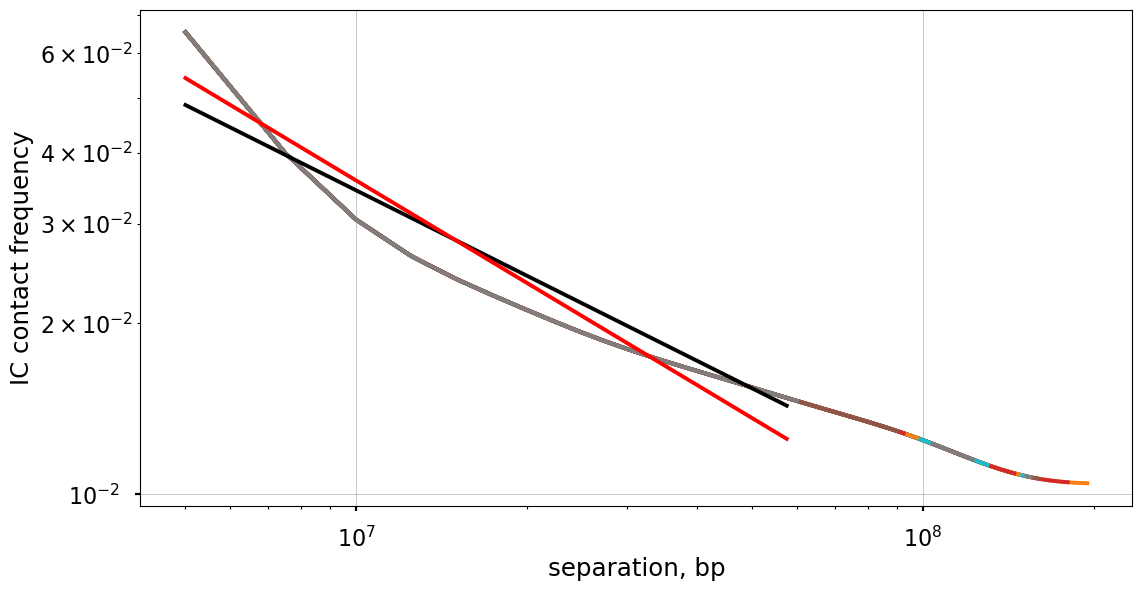

#### Plot the smoothed P(s) curve and its derivative

Logbin-smoothing of P(s) reduces the "fanning" at longer s and enables us to plot the derivative of the P(s) curve in the log-log space. This derivative is extremely informative, as it can be compared to predictions from various polymer models.

In [133]:
# Just take a single value for each genomic separation
cvd_merged = cvd_smooth_agg.drop_duplicates(subset=['dist'])[['dist_bp', 'balanced.avg.smoothed.agg']]

In [134]:
# Calculate derivative in log-log space
der = np.gradient(np.log(cvd_merged['balanced.avg.smoothed.agg']),
                  np.log(cvd_merged['dist_bp']))

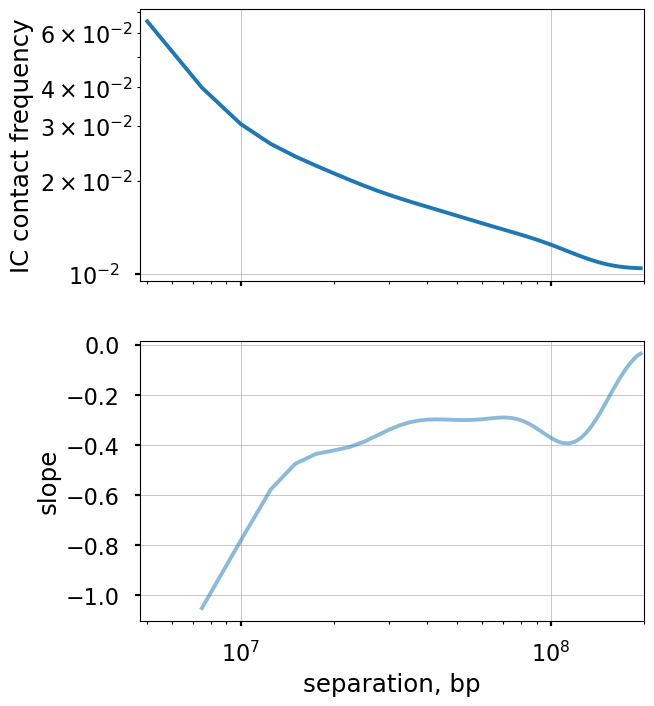

In [190]:
f, axs = plt.subplots(
    figsize=(6.5,8),
    nrows=2, 
    gridspec_kw={'height_ratios':[2,2]}, 
    sharex=True)
ax = axs[0]
ax.loglog(
    cvd_merged['dist_bp'],
    cvd_merged['balanced.avg.smoothed.agg'],
    '-'
)

ax.set(
    ylabel='IC contact frequency',
    xlim=(4.75 * 1e6, 2 * 1e8)
)
ax.set_aspect(1.0)
ax.grid(lw=0.5)


ax = axs[1]
ax.semilogx(
    cvd_merged['dist_bp'],
    der,
    alpha=0.5
)

ax.set(
    xlabel='separation, bp', 
    ylabel='slope',
    xlim=(4.75 * 1e6, 2 * 1e8))

ax.grid(lw=0.5)

plt.show()

### Impact of sequencing depth on computed P(s)

We explore the influence of sequencing coverage on calculating P(s) curves using cooltools.sample() to generate downsampled coolers from the Kreitenstein microC test dataset. We then compute raw P(s) and smoothed P(s) at various levels of downsampling, for the q arm of chr2.

Raw P(s) appear very noisy even with 0.1% downsampling. Smoothed P(s) are fairly consistent down to 0.01% downsampling. Derivatives, however, are less reliable at 0.01% downsampling.

In [31]:
# create downsampled test data 
downsampling_fracs = [0.0001, 0.001]
num_reads = {}
cvds = {}
cvds_smoothed = {}
derivs_smoothed = {}

p = Pool(num_cpus)
for frac in downsampling_fracs:
    cooltools.sample(clr, out_clr_path=f'./data/test_sampled_{frac}_.cool', frac=frac, nproc=num_cpus)

    clr_downsampled = cooler.Cooler(f'./data/test_sampled_{frac}_.cool')
    result = cooler.balance_cooler(clr_downsampled, map=p.map, store=True, min_nnz=0)
p.close()
p.terminate()

INFO:root:creating a Pool of 10 workers
INFO:root:creating a Pool of 10 workers


In [32]:
# expected & derivative calculation for raw data, using only the second arm of chr2
cvd_smooth_agg_raw = cooltools.expected_cis(
    clr=clr,
    view_df=mm10_arms[1:2],
    clr_weight_name=None,
    smooth=True,
    aggregate_smoothed=True,
    nproc=num_cpus
)

cvd_smooth_agg_raw['count.avg.smoothed'].loc[cvd_smooth_agg_raw['dist'] < 2] = np.nan
cvd_merged = cvd_smooth_agg_raw.drop_duplicates(subset=['dist'])[['dist_bp', 'count.avg.smoothed.agg']]
der = np.gradient(np.log(cvd_merged['count.avg.smoothed.agg']),
                np.log(cvd_merged['dist_bp']))    
deriv_smoothed_raw  = der


cvds[1.0] = cvd_smooth_agg_raw.copy()
cvds_smoothed[1.0]= cvd_smooth_agg_raw.copy()
num_reads[1.0] = cvd_smooth_agg_raw['count.sum'].sum().astype(int)
derivs_smoothed[1.0] = deriv_smoothed_raw


INFO:root:creating a Pool of 10 workers


In [39]:
# expected calculation for the downsampled data
for frac in downsampling_fracs:
    clr_downsampled = cooler.Cooler(f'./data/test_sampled_{frac}_.cool')
    
    cvd_downsampled = cooltools.expected_cis(
        clr=clr_downsampled,
        view_df=mm10_arms[1:2],
        clr_weight_name=None,
        smooth=False,
        aggregate_smoothed=False,
        nproc=num_cpus #if you do not have multiple cores available, set to 1
    )
    cvds[frac] = cvd_downsampled
    num_reads[frac] = cvd_downsampled['count.sum'].sum().astype(int) 

INFO:root:creating a Pool of 10 workers


INFO:root:creating a Pool of 10 workers


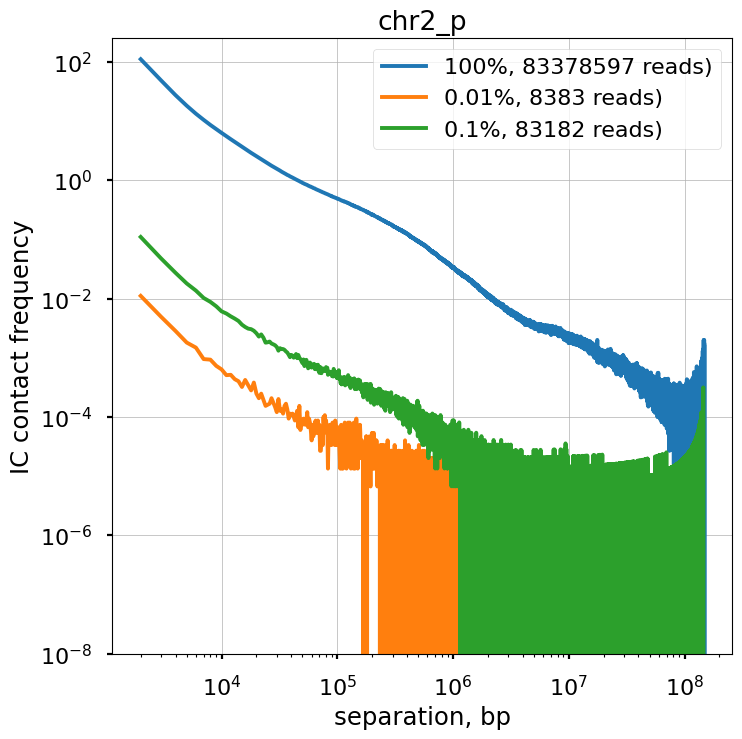

In [42]:
f, ax = plt.subplots(1,1, figsize=(8, 8))

region = mm10_arms['name'][0]
for frac in [1]+downsampling_fracs:
    cvd_downsampled = cvds[frac]
    ax.loglog(
        cvd_downsampled['dist_bp'],
        cvd_downsampled['count.avg'],
        label=f'{frac*100}%, {num_reads[frac]} reads',
    )

ax.set(
    xlabel='separation, bp', 
    ylabel='contact frequency')
ax.grid(lw=0.5)
ax.legend() 
ax.title.set_text(region)
ax.set_ylim(ymin=10**(-8))
f.show()

In [43]:
# expected calculation for the smoothed data
for frac in downsampling_fracs:
    clr_downsampled = cooler.Cooler(f'./data/test_sampled_{frac}_.cool')
    cvd_smooth_agg_downsampled = cooltools.expected_cis(
        clr=clr_downsampled,
        view_df=mm10_arms[1:2],
        clr_weight_name=None,
        smooth=True,
        aggregate_smoothed=True,
        nproc=num_cpus
    )
    cvd_smooth_agg_downsampled['count.avg.smoothed'].loc[cvd_smooth_agg_downsampled['dist'] < 2] = np.nan
    cvds_smoothed[frac] = cvd_smooth_agg_downsampled

    cvd_merged = cvd_smooth_agg_downsampled.drop_duplicates(subset=['dist'])[['dist_bp', 'count.avg.smoothed.agg']]
    der = np.gradient(np.log(cvd_merged['count.avg.smoothed.agg']),
                    np.log(cvd_merged['dist_bp']))    
    derivs_smoothed[frac] = der
    


INFO:root:creating a Pool of 10 workers


INFO:root:creating a Pool of 10 workers


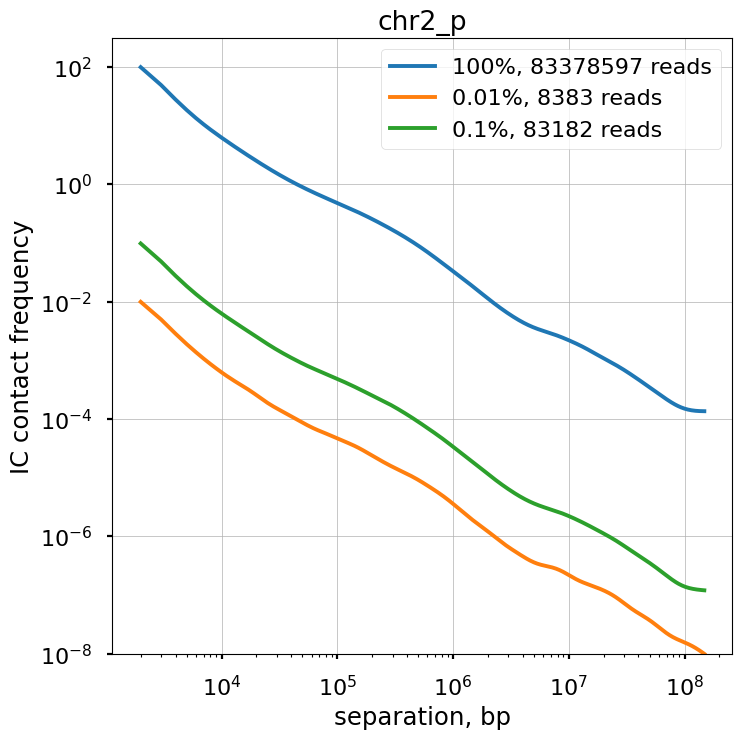

In [47]:
f, ax = plt.subplots(1,1,figsize=(8, 8))

for frac in [1]+downsampling_fracs:
    cvd_smooth_agg_downsampled = cvds_smoothed[frac]
    cvd_smooth_agg_downsampled['count.avg.smoothed'].loc[cvd_smooth_agg_downsampled['dist'] < 2] = np.nan
    ax.loglog(
        cvd_smooth_agg_downsampled['dist_bp'],
        cvd_smooth_agg_downsampled['count.avg.smoothed'],
        label=f'{frac*100}%, {num_reads[frac]} reads')
    
ax.set(
    xlabel='separation, bp', 
    ylabel='contact frequency')
ax.grid(lw=0.5)
ax.title.set_text(region)
ax.legend()
ax.set_ylim(ymin=10**(-8))
f.show()

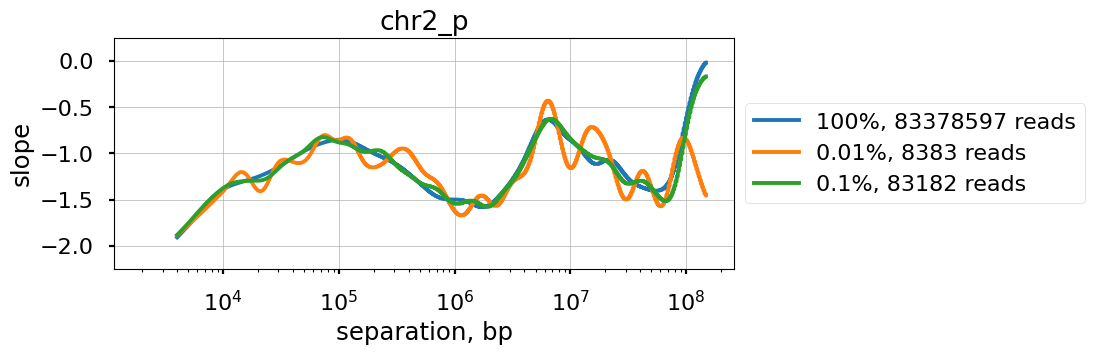

In [56]:
f, ax = plt.subplots(1,1,figsize=(8,3))
for frac in [1]+downsampling_fracs:
    der = derivs_smoothed[frac]
    der[3] = np.nan
    ax.semilogx(
        cvd_smooth_agg_downsampled['dist_bp'],
        der,
        label=f'{frac*100}%, {num_reads[frac]} reads'
        )

ax.set(
    xlabel='separation, bp', 
    ylabel='slope')
ax.grid(lw=0.5)
ax.title.set_text(region)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylim(-2.25,.25)
f.show()